# Day 21 — Sentiment Analysis
## Mini Project: Product Review Sentiment Analyzer

**Objective:** Build a complete beginner-friendly NLP project that classifies product reviews as **Positive** or **Negative**.

Pipeline:

`Review → Preprocessing → TF-IDF → Logistic Regression → Sentiment`


## 1. Import Libraries

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)


## 2. Create a Small Product Review Dataset

`1 = Positive`  
`0 = Negative`

This is a small teaching dataset. A real-world application should use a much larger labeled dataset.


In [ ]:
reviews = [
    "This product is amazing",
    "Excellent quality and great service",
    "I love this product",
    "Very happy with my purchase",
    "The product works perfectly",
    "Amazing experience and fast delivery",
    "Good quality product",
    "I am satisfied with this purchase",
    "The quality is excellent",
    "Really useful and easy to use",
    "Fantastic product",
    "The service was wonderful",
    "This product is terrible",
    "Very poor quality",
    "I hate this product",
    "Very disappointed with my purchase",
    "The product stopped working",
    "Terrible experience",
    "Bad quality product",
    "I am not satisfied",
    "The quality is horrible",
    "Waste of money",
    "The service was very poor",
    "Delivery was late and the product was damaged"
]

labels = [1]*12 + [0]*12

df = pd.DataFrame({"review": reviews, "sentiment": labels})
df


,review,sentiment
0,This product is amazing,1
1,Excellent quality and great service,1
2,I love this product,1
3,Very happy with my purchase,1
4,The product works perfectly,1
5,Amazing experience and fast delivery,1
6,Good quality product,1
7,I am satisfied with this purchase,1
8,The quality is excellent,1
9,Really useful and easy to use,1


## 3. Understand the Dataset

In [ ]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["sentiment"].value_counts())

df["sentiment_label"] = df["sentiment"].map({1: "Positive", 0: "Negative"})
df[["review", "sentiment_label"]]


Shape: (24, 2)

Missing values:
review       0
sentiment    0
dtype: int64

Class distribution:
sentiment
1    12
0    12
Name: count, dtype: int64


,review,sentiment_label
0,This product is amazing,Positive
1,Excellent quality and great service,Positive
2,I love this product,Positive
3,Very happy with my purchase,Positive
4,The product works perfectly,Positive
5,Amazing experience and fast delivery,Positive
6,Good quality product,Positive
7,I am satisfied with this purchase,Positive
8,The quality is excellent,Positive
9,Really useful and easy to use,Positive


## 4. Visualize Sentiment Distribution

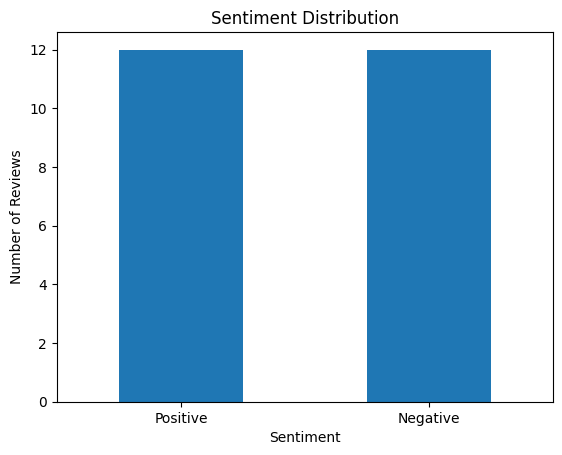

In [ ]:
df["sentiment_label"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()


## 5. Text Preprocessing

For this project we will:
- convert text to lowercase
- remove punctuation/special characters
- normalize extra spaces

We keep the preprocessing simple so the focus remains on sentiment classification.


In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_review"] = df["review"].apply(preprocess_text)
df[["review", "clean_review"]]


,review,clean_review
0,This product is amazing,this product is amazing
1,Excellent quality and great service,excellent quality and great service
2,I love this product,i love this product
3,Very happy with my purchase,very happy with my purchase
4,The product works perfectly,the product works perfectly
5,Amazing experience and fast delivery,amazing experience and fast delivery
6,Good quality product,good quality product
7,I am satisfied with this purchase,i am satisfied with this purchase
8,The quality is excellent,the quality is excellent
9,Really useful and easy to use,really useful and easy to use


## 6. Separate Features and Labels

In [ ]:
X = df["clean_review"]
y = df["sentiment"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (24,)
y shape: (24,)


## 7. Train-Test Split

We use 75% for training and 25% for testing.

`stratify=y` keeps the positive/negative class proportions approximately consistent.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 18
Testing samples: 6


## 8. TF-IDF Feature Extraction

Machine Learning models need numerical input.

We fit TF-IDF **only on the training data** and then transform the test data. This avoids leaking test-set information into training.


In [ ]:
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)


Training matrix shape: (18, 39)
Testing matrix shape: (6, 39)


## 9. Train Logistic Regression

Logistic Regression is a simple baseline model for binary text classification.

`TF-IDF → Logistic Regression → Positive / Negative`


In [ ]:
model = LogisticRegression(random_state=42)
model.fit(X_train_tfidf, y_train)

print("Model training completed.")


Model training completed.


## 10. Make Predictions

In [ ]:
y_pred = model.predict(X_test_tfidf)

results = pd.DataFrame({
    "Review": X_test.values,
    "Actual": y_test.values,
    "Predicted": y_pred
})

results


,Review,Actual,Predicted
0,bad quality product,0,1
1,the service was wonderful,1,0
2,i am satisfied with this purchase,1,1
3,i love this product,1,0
4,very disappointed with my purchase,0,1
5,i am not satisfied,0,1


## 11. Evaluate the Model

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1-Score : {f1:.2f}")


Accuracy : 0.17
Precision: 0.25
Recall   : 0.33
F1-Score : 0.29


## 12. Classification Report

In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"],
    zero_division=0
))


              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         3
    Positive       0.25      0.33      0.29         3

    accuracy                           0.17         6
   macro avg       0.12      0.17      0.14         6
weighted avg       0.12      0.17      0.14         6



## 13. Confusion Matrix

The confusion matrix shows correct and incorrect predictions for each class.


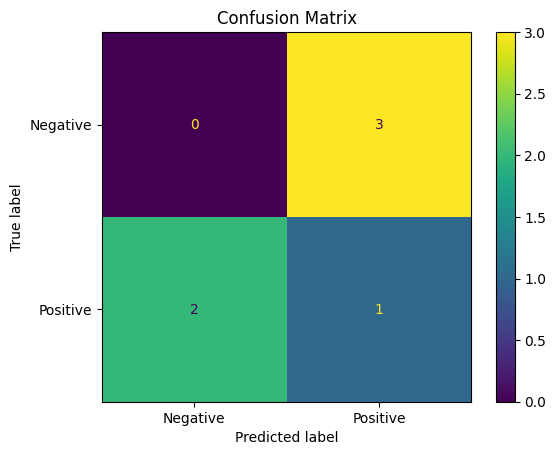

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


## 14. Predict a New Review

In [ ]:
def predict_sentiment(text):
    cleaned = preprocess_text(text)
    vector = tfidf.transform([cleaned])

    prediction = model.predict(vector)[0]
    probability = model.predict_proba(vector)[0].max()

    sentiment = "Positive 😊" if prediction == 1 else "Negative 😞"
    return sentiment, probability

test_reviews = [
    "The product is excellent and I love it",
    "This is a terrible product",
    "Very good quality and fast service",
    "I am disappointed and unhappy"
]

for review in test_reviews:
    sentiment, probability = predict_sentiment(review)
    print("Review:", review)
    print("Prediction:", sentiment)
    print(f"Model probability: {probability:.2f}")
    print("-" * 50)


Review: The product is excellent and I love it
Prediction: Positive 😊
Model probability: 0.59
--------------------------------------------------
Review: This is a terrible product
Prediction: Negative 😞
Model probability: 0.59
--------------------------------------------------
Review: Very good quality and fast service
Prediction: Positive 😊
Model probability: 0.58
--------------------------------------------------
Review: I am disappointed and unhappy
Prediction: Positive 😊
Model probability: 0.58
--------------------------------------------------


## 15. Important Note

`predict_proba()` gives the model's estimated class probability. It is not a guarantee that the prediction is correct.


# 16. Complete Project Pipeline

```text
Product Review
      ↓
Text Preprocessing
      ↓
Train / Test Split
      ↓
TF-IDF
      ↓
Logistic Regression
      ↓
Prediction
      ↓
Evaluation
      ↓
Positive / Negative
```


# 17. Key Takeaways

- Sentiment Analysis is an NLP classification task.
- Text must be converted into numerical features.
- TF-IDF is a useful traditional text representation.
- Logistic Regression can classify positive and negative reviews.
- Accuracy, precision, recall and F1-score help evaluate the classifier.

### Final Concept

**Review → Preprocess → TF-IDF → Classifier → Sentiment**
